# Largest Monotonically Increasing Subsequence 

In [7]:
# Data Soal
sequence = [4, 1, 13, 7, 0, 2, 8, 11, 3]

def find_longest_increasing_subsequence(arr):
    # Kita gunakan struktur Recursive dengan Memoization (supaya efisien)
    # Tapi karena soal meminta pendekatan Tree, kita simulasikan cara kerja tree
    
    # Fungsi untuk mencari kedalaman maksimal dari index tertentu
    def search_tree(current_index, current_val):
        # Cari anak-anak yang valid (index > current_index DAN value > current_val)
        possible_next_steps = []
        for i in range(current_index + 1, len(arr)):
            if arr[i] > current_val:
                # Rekursif: Lanjut cari ke dalam
                path_from_child = search_tree(i, arr[i])
                possible_next_steps.append(path_from_child)
        
        # Jika tidak ada langkah lagi (daun/leaf), kembalikan diri sendiri
        if not possible_next_steps:
            return [current_val]
        
        # Jika ada cabang, pilih cabang yang menghasilkan jalur TERPANJANG
        longest_subpath = max(possible_next_steps, key=len)
        return [current_val] + longest_subpath

    # Level 1: Coba mulai dari setiap angka di deret
    all_possible_paths = []
    for i in range(len(arr)):
        path = search_tree(i, arr[i])
        all_possible_paths.append(path)
    
    # Ambil pemenang (paling panjang)
    winner = max(all_possible_paths, key=len)
    return winner

# Eksekusi
solusi = find_longest_increasing_subsequence(sequence)
print(f"Data Awal: {sequence}")
print(f"Subsequence Terpanjang (LIS): {solusi}")
print(f"Panjang Langkah: {len(solusi)}")

Data Awal: [4, 1, 13, 7, 0, 2, 8, 11, 3]
Subsequence Terpanjang (LIS): [4, 7, 8, 11]
Panjang Langkah: 4


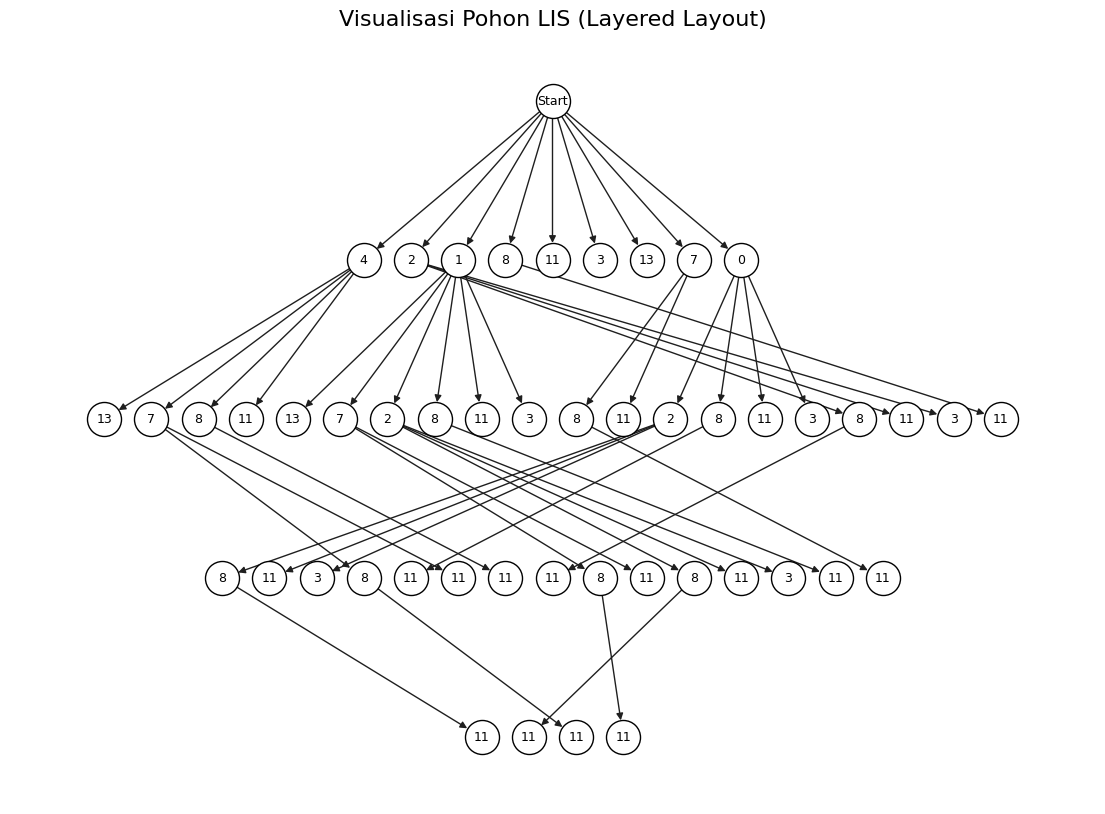

In [17]:
import networkx as nx
import matplotlib.pyplot as plt

# Data Soal
sequence = [4, 1, 13, 7, 0, 2, 8, 11, 3]

# Membuat Graf Berarah
G = nx.DiGraph()
labels = {}
node_id_counter = 0

# --- FUNGSI PEMBANGUN POHON YANG DIPERBAIKI ---
# Kita tambahkan parameter 'level' untuk mencatat kedalaman node
def build_visual_tree_layered(parent_id, current_idx, current_val, level):
    global node_id_counter
    
    for i in range(current_idx + 1, len(sequence)):
        if sequence[i] > current_val:
            node_id_counter += 1
            my_id = node_id_counter
            
            # Tambahkan Node dengan atribut 'layer'
            # Semakin dalam levelnya, semakin ke bawah posisinya nanti
            G.add_node(my_id, layer=level)
            G.add_edge(parent_id, my_id)
            labels[my_id] = sequence[i]
            
            # Rekursif ke level berikutnya
            build_visual_tree_layered(my_id, i, sequence[i], level + 1)

# Setup Root (Titik Awal) di layer 0
root_id = 0
G.add_node(root_id, layer=0)
labels[root_id] = "Start"

# Jalankan fungsi pembangun mulai dari level 1
build_visual_tree_layered(root_id, -1, -1, 1)

# --- BAGIAN MENGGAMBAR YANG DIPERBAIKI ---
plt.figure(figsize=(14, 10)) # Ukuran gambar diperbesar

# --- KUNCI PERBAIKAN: Gunakan Multipartite Layout ---
# Layout ini akan menyusun node berdasarkan atribut 'layer' yang kita buat tadi
pos = nx.multipartite_layout(G, subset_key='layer', align='horizontal')

# Gambar Node, Edge, dan Label
# Kita perkecil sedikit node dan font agar muat banyak
nx.draw_networkx_nodes(G, pos, node_size=600, node_color='white', edgecolors='black')
nx.draw_networkx_edges(G, pos, edge_color='#1f1f1f', arrows=True, arrowstyle='-|>', node_size=600)
nx.draw_networkx_labels(G, pos, labels=labels, font_size=9)

plt.title("Visualisasi Pohon LIS (Layered Layout)", fontsize=16)
# Membalik sumbu Y agar Start ada di atas dan pohon tumbuh ke bawah
plt.gca().invert_yaxis()
plt.axis('off')
plt.show()